In [1]:
#Cell 1 — Imports and Load Subset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (14, 5)
sns.set_theme(style='whitegrid')

# Load the subset saved on Day 2
sales   = pd.read_csv('../data/processed/subset_CA1_FOODS.csv')
calendar = pd.read_csv('../data/raw/calendar.csv')
prices   = pd.read_csv('../data/raw/sell_prices.csv')

print(f"✅ Sales subset: {sales.shape}")
print(f"✅ Calendar:     {calendar.shape}")
print(f"✅ Prices:       {prices.shape}")

✅ Sales subset: (1437, 1920)
✅ Calendar:     (1969, 14)
✅ Prices:       (6841121, 4)


In [2]:
#Cell 2 — Melt Sales to Long Format
id_cols  = ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
day_cols = [col for col in sales.columns if col.startswith('d_')]

df = sales[id_cols + day_cols].melt(
    id_vars=id_cols,
    var_name='d',
    value_name='units_sold'
)

# Convert d_1, d_2... to integers for sorting
df['d_num'] = df['d'].str.replace('d_', '').astype(int)
df = df.sort_values(['id', 'd_num']).reset_index(drop=True)

print(f"✅ Long format shape: {df.shape}")
print(f"   Rows = {sales.shape[0]} products × {len(day_cols)} days = {sales.shape[0]*len(day_cols):,}")
print(df.head(8))

✅ Long format shape: (2748981, 9)
   Rows = 1437 products × 1913 days = 2,748,981
                            id      item_id  dept_id cat_id store_id state_id  \
0  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
1  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
2  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
3  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
4  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
5  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
6  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   
7  FOODS_1_001_CA_1_validation  FOODS_1_001  FOODS_1  FOODS     CA_1       CA   

     d  units_sold  d_num  
0  d_1           3      1  
1  d_2           0      2  
2  d_3           0      3  
3  d_4           1      4  
4  d_5           4      5  
5  d_6           2  

In [3]:
#Cell 3 — Merge Calendar Features
calendar['d_num'] = calendar['d'].str.replace('d_', '').astype(int)

cal_cols = ['d_num', 'date', 'wm_yr_wk', 'weekday', 'wday',
            'month', 'year', 'event_name_1', 'event_type_1',
            'snap_CA', 'snap_TX', 'snap_WI']

df = df.merge(calendar[cal_cols], on='d_num', how='left')
df['date'] = pd.to_datetime(df['date'])

print(f"✅ After calendar merge: {df.shape}")
print(df[['id','date','units_sold','wday','month','snap_CA','event_name_1']].head(8))

✅ After calendar merge: (2748981, 20)
                            id       date  units_sold  wday  month  snap_CA  \
0  FOODS_1_001_CA_1_validation 2011-01-29           3     1      1        0   
1  FOODS_1_001_CA_1_validation 2011-01-30           0     2      1        0   
2  FOODS_1_001_CA_1_validation 2011-01-31           0     3      1        0   
3  FOODS_1_001_CA_1_validation 2011-02-01           1     4      2        1   
4  FOODS_1_001_CA_1_validation 2011-02-02           4     5      2        1   
5  FOODS_1_001_CA_1_validation 2011-02-03           2     6      2        1   
6  FOODS_1_001_CA_1_validation 2011-02-04           0     7      2        1   
7  FOODS_1_001_CA_1_validation 2011-02-05           2     1      2        1   

  event_name_1  
0          NaN  
1          NaN  
2          NaN  
3          NaN  
4          NaN  
5          NaN  
6          NaN  
7          NaN  


In [4]:
#Cell 4 — Merge Price Features
prices_subset = prices[prices['store_id'] == 'CA_1'].copy()

df = df.merge(
    prices_subset[['item_id', 'wm_yr_wk', 'sell_price']],
    on=['item_id', 'wm_yr_wk'],
    how='left'
)

missing_price_pct = df['sell_price'].isna().mean() * 100
print(f"✅ After price merge: {df.shape}")
print(f"   Missing prices: {missing_price_pct:.1f}%")

# Fill missing prices with item's median price
df['sell_price'] = df.groupby('item_id')['sell_price'].transform(
    lambda x: x.fillna(x.median())
)
print(f"   Missing after fill: {df['sell_price'].isna().sum()}")

✅ After price merge: (2748981, 21)
   Missing prices: 19.2%
   Missing after fill: 0


In [5]:
#Cell 5 — Lag Features(How much did this product sell N days ago?)
# Sort before creating lags — critical
df = df.sort_values(['id', 'date']).reset_index(drop=True)

# Lags: 7, 14, 28 days (avoid data leakage — never lag < forecast horizon)
lag_days = [7, 14, 28]

for lag in lag_days:
    df[f'lag_{lag}'] = df.groupby('id')['units_sold'].shift(lag)

print("✅ Lag features created:")
print(df[['id', 'date', 'units_sold', 'lag_7', 'lag_14', 'lag_28']].head(35).tail(8))

✅ Lag features created:
                             id       date  units_sold  lag_7  lag_14  lag_28
27  FOODS_1_001_CA_1_validation 2011-02-25           4    2.0     1.0     NaN
28  FOODS_1_001_CA_1_validation 2011-02-26           2    1.0     3.0     3.0
29  FOODS_1_001_CA_1_validation 2011-02-27           2    2.0     0.0     0.0
30  FOODS_1_001_CA_1_validation 2011-02-28           0    0.0     2.0     0.0
31  FOODS_1_001_CA_1_validation 2011-03-01           2    2.0     1.0     1.0
32  FOODS_1_001_CA_1_validation 2011-03-02           1    2.0     2.0     4.0
33  FOODS_1_001_CA_1_validation 2011-03-03           7    2.0     0.0     2.0
34  FOODS_1_001_CA_1_validation 2011-03-04           1    4.0     2.0     0.0


In [6]:
#Cell 6 — Rolling Mean Features(What's the recent trend for this product?)
windows = [7, 14, 28]

for w in windows:
    df[f'roll_mean_{w}'] = (
        df.groupby('id')['units_sold']
        .shift(7)                          # shift first to prevent leakage
        .transform(lambda x: x.rolling(w, min_periods=1).mean())
    )
    df[f'roll_std_{w}'] = (
        df.groupby('id')['units_sold']
        .shift(7)
        .transform(lambda x: x.rolling(w, min_periods=1).std())
    )

print("✅ Rolling features created:")
print(df[['id','date','units_sold','roll_mean_7','roll_mean_28','roll_std_28']].head(40).tail(5))

✅ Rolling features created:
                             id       date  units_sold  roll_mean_7  \
35  FOODS_1_001_CA_1_validation 2011-03-05           2     2.000000   
36  FOODS_1_001_CA_1_validation 2011-03-06           3     2.000000   
37  FOODS_1_001_CA_1_validation 2011-03-07           0     2.000000   
38  FOODS_1_001_CA_1_validation 2011-03-08           1     2.000000   
39  FOODS_1_001_CA_1_validation 2011-03-09           2     1.857143   

    roll_mean_28  roll_std_28  
35      1.357143     1.253566  
36      1.428571     1.230133  
37      1.428571     1.230133  
38      1.464286     1.231745  
39      1.357143     1.129218  


In [7]:
#Cell 7 — Calendar Features
# Day of week (already in data as wday 1-7, make it 0-6 for model)
df['day_of_week'] = df['date'].dt.dayofweek       # 0=Mon, 6=Sun
df['day_of_month'] = df['date'].dt.day
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['quarter'] = df['date'].dt.quarter
df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

# SNAP days (government food-stamp purchase days — huge signal for FOODS)
df['is_snap'] = df['snap_CA'].fillna(0).astype(int)

# Holiday/event flag
df['is_event'] = df['event_name_1'].notna().astype(int)
df['is_sporting_event'] = (df['event_type_1'] == 'Sporting').astype(int)
df['is_cultural_event'] = (df['event_type_1'] == 'Cultural').astype(int)
df['is_national_holiday'] = (df['event_type_1'] == 'National').astype(int)
df['is_religious_event'] = (df['event_type_1'] == 'Religious').astype(int)

print("✅ Calendar features created")
print(df[['date','day_of_week','is_weekend','is_snap','is_event']].head(10))

✅ Calendar features created
        date  day_of_week  is_weekend  is_snap  is_event
0 2011-01-29            5           1        0         0
1 2011-01-30            6           1        0         0
2 2011-01-31            0           0        0         0
3 2011-02-01            1           0        1         0
4 2011-02-02            2           0        1         0
5 2011-02-03            3           0        1         0
6 2011-02-04            4           0        1         0
7 2011-02-05            5           1        1         0
8 2011-02-06            6           1        1         1
9 2011-02-07            0           0        1         0


In [8]:
#Cell 8 — Price Features
# Price change from last week
df['price_lag_7'] = df.groupby('id')['sell_price'].shift(7)
df['price_change'] = df['sell_price'] - df['price_lag_7']
df['price_change_pct'] = df['price_change'] / (df['price_lag_7'] + 1e-8)

# Is this product on discount vs its own history?
df['price_vs_mean'] = df['sell_price'] / df.groupby('id')['sell_price'].transform('mean')
df['is_price_drop'] = (df['price_change'] < 0).astype(int)

print("✅ Price features created")
print(df[['id','date','sell_price','price_change_pct','price_vs_mean','is_price_drop']].head(40).tail(5))

✅ Price features created
                             id       date  sell_price  price_change_pct  \
35  FOODS_1_001_CA_1_validation 2011-03-05         2.0               0.0   
36  FOODS_1_001_CA_1_validation 2011-03-06         2.0               0.0   
37  FOODS_1_001_CA_1_validation 2011-03-07         2.0               0.0   
38  FOODS_1_001_CA_1_validation 2011-03-08         2.0               0.0   
39  FOODS_1_001_CA_1_validation 2011-03-09         2.0               0.0   

    price_vs_mean  is_price_drop  
35       0.922888              0  
36       0.922888              0  
37       0.922888              0  
38       0.922888              0  
39       0.922888              0  


In [9]:
#Cell 9 — Drop Rows with NaN Lags and Save
feature_cols = [
    # Lags
    'lag_7', 'lag_14', 'lag_28',
    # Rolling
    'roll_mean_7', 'roll_mean_14', 'roll_mean_28',
    'roll_std_7', 'roll_std_14', 'roll_std_28',
    # Calendar
    'day_of_week', 'day_of_month', 'week_of_year',
    'quarter', 'is_weekend', 'is_month_start', 'is_month_end',
    'is_snap', 'is_event', 'is_sporting_event',
    'is_cultural_event', 'is_national_holiday', 'is_religious_event',
    # Price
    'sell_price', 'price_change_pct', 'price_vs_mean', 'is_price_drop',
    # Target
    'units_sold',
    # Metadata (not features, needed for splits)
    'id', 'item_id', 'dept_id', 'date', 'd_num'
]

df_model = df[feature_cols].dropna().reset_index(drop=True)

print(f"✅ Final dataset shape: {df_model.shape}")
print(f"   Rows dropped (NaN lags): {len(df) - len(df_model):,}")
print(f"   Features ready for model: {len(feature_cols) - 5}")  # minus metadata cols

df_model.to_parquet('../data/features/ca1_foods_features.parquet', index=False)
print("✅ Saved to data/features/ca1_foods_features.parquet")

✅ Final dataset shape: (2708745, 32)
   Rows dropped (NaN lags): 40,236
   Features ready for model: 27
✅ Saved to data/features/ca1_foods_features.parquet


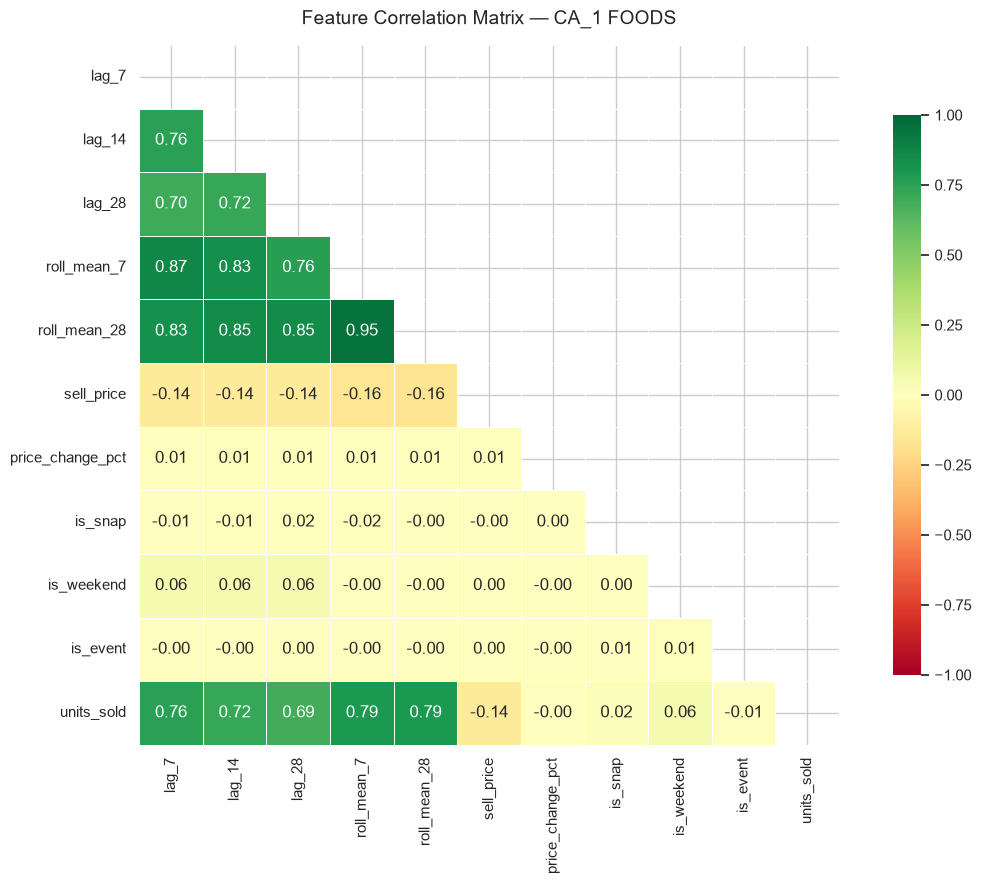

✅ Saved correlation heatmap


In [12]:
#Cell 10 — Feature Correlation Heatmap
numeric_features = [
    'lag_7', 'lag_14', 'lag_28',
    'roll_mean_7', 'roll_mean_28',
    'sell_price', 'price_change_pct',
    'is_snap', 'is_weekend', 'is_event',
    'units_sold'
]

corr = df_model[numeric_features].corr()

plt.figure(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    square=True, linewidths=0.5,
    cbar_kws={'shrink': 0.8}
)
plt.title('Feature Correlation Matrix — CA_1 FOODS', fontsize=14, pad=15)
plt.tight_layout()
plt.savefig('../outputs/shap_plots/04_feature_correlation.png', bbox_inches='tight')
plt.show()
print("✅ Saved correlation heatmap")

In [13]:
#Cell 11 — Feature Engineering Summary
print("=" * 55)
print("Feature Engineering Summary — ExplainStock")
print("=" * 55)

feature_groups = {
    'Lag features':     ['lag_7', 'lag_14', 'lag_28'],
    'Rolling features': ['roll_mean_7', 'roll_mean_14', 'roll_mean_28',
                         'roll_std_7', 'roll_std_14', 'roll_std_28'],
    'Calendar features':['day_of_week', 'is_weekend', 'is_snap',
                         'is_event', 'is_national_holiday', 'week_of_year'],
    'Price features':   ['sell_price', 'price_change_pct',
                         'price_vs_mean', 'is_price_drop'],
}

for group, feats in feature_groups.items():
    print(f"\n  {group} ({len(feats)}):")
    for f in feats:
        print(f"    • {f}")

print(f"\n  Total features : {sum(len(v) for v in feature_groups.values())}")
print(f"  Total rows     : {len(df_model):,}")
print(f"  Date range     : {df_model['date'].min().date()} → {df_model['date'].max().date()}")
print("\n✅ Day 3-4 complete. Next: XGBoost model training (Day 5-6)")

Feature Engineering Summary — ExplainStock

  Lag features (3):
    • lag_7
    • lag_14
    • lag_28

  Rolling features (6):
    • roll_mean_7
    • roll_mean_14
    • roll_mean_28
    • roll_std_7
    • roll_std_14
    • roll_std_28

  Calendar features (6):
    • day_of_week
    • is_weekend
    • is_snap
    • is_event
    • is_national_holiday
    • week_of_year

  Price features (4):
    • sell_price
    • price_change_pct
    • price_vs_mean
    • is_price_drop

  Total features : 19
  Total rows     : 2,708,745
  Date range     : 2011-02-26 → 2016-04-24

✅ Day 3-4 complete. Next: XGBoost model training (Day 5-6)
